In [1]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [2]:
string_d256 = pd.read_csv('../../../../../../../../s/project/gene_embedding/funcrvp_embeddings/STRING_EXP_d128.tsv', sep='\t')
string_d256


,gene_id,node2vec_STRING_EXP_0,node2vec_STRING_EXP_1,node2vec_STRING_EXP_2,node2vec_STRING_EXP_3,node2vec_STRING_EXP_4,node2vec_STRING_EXP_5,node2vec_STRING_EXP_6,node2vec_STRING_EXP_7,node2vec_STRING_EXP_8,...,verse_STRING_EXP_118,verse_STRING_EXP_119,verse_STRING_EXP_120,verse_STRING_EXP_121,verse_STRING_EXP_122,verse_STRING_EXP_123,verse_STRING_EXP_124,verse_STRING_EXP_125,verse_STRING_EXP_126,verse_STRING_EXP_127
0,ENSG00000000003,0.116546,-0.279824,-0.112550,-0.459303,-0.239372,0.186485,0.264236,0.017883,-0.244099,...,-0.852502,0.849152,0.347221,0.958687,-0.632295,0.173431,-0.274903,-1.002037,-0.189800,0.511142
1,ENSG00000000005,-0.014115,-0.338361,-0.077789,-0.402543,-0.457482,0.216110,0.282357,-0.012062,-0.235869,...,-0.710637,0.767541,0.471644,1.213388,-0.263752,0.252265,-0.171008,-1.065229,-0.152363,0.165927
2,ENSG00000000419,0.302636,0.072656,0.158833,-0.201725,0.003735,-0.320876,0.016339,-0.204459,-0.035872,...,-1.040879,1.055397,-0.563956,1.255999,-0.502084,-0.019668,-0.580033,-0.575159,-0.107873,-0.321708
3,ENSG00000000457,0.154597,-0.470136,-0.006066,-0.251336,-0.003624,-0.191942,-0.000935,-0.079171,-0.066484,...,-0.972075,0.814683,-0.414577,1.192199,-0.399942,0.064400,-0.782525,-0.546478,-0.127678,-0.087233
4,ENSG00000000460,0.115192,-0.350561,0.111642,-0.008045,-0.064833,-0.267716,-0.032430,-0.096132,0.241286,...,-0.582103,1.072941,0.055873,1.296314,-0.457694,0.530696,-0.773988,-0.519909,0.415668,-0.560442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18706,ENSG00000279911,0.553511,-0.452050,0.115386,-0.164925,-0.698515,-0.013901,0.437031,0.029798,0.226568,...,-0.857214,0.623529,-1.012692,0.449873,-0.576930,-0.159524,0.153431,-0.317198,-0.204590,-0.198232
18707,ENSG00000279941,0.551800,-0.337775,0.168311,-0.171650,-0.674667,0.056141,0.502153,-0.049951,0.167012,...,-0.628170,0.483853,-0.679436,0.656934,-0.696363,-0.056190,0.210962,-0.495034,-0.260303,-0.410423
18708,ENSG00000279973,-0.004263,-0.304996,-0.017881,-0.207718,-0.240242,-0.143710,0.117032,-0.138547,0.017181,...,-0.401178,0.679386,-0.025044,0.483669,-0.385183,-0.202823,-0.053097,-0.777500,0.100124,-0.426191
18709,ENSG00000280165,0.241998,-0.283730,-0.069694,-0.360203,-0.415328,0.261201,0.314894,0.044914,-0.260483,...,-0.708250,0.567962,-0.523431,1.189254,-0.413536,0.558179,-0.009133,-1.040424,0.296491,-0.135329


In [3]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [4]:
cancer_gene_columns = emogi_predictions[['ID', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = string_d256.merge(cancer_gene_columns, left_on="gene_id" ,right_on='ID', how='inner').drop(columns=['ID'])
merged.set_index('gene_id', inplace=True)
merged

,node2vec_STRING_EXP_0,node2vec_STRING_EXP_1,node2vec_STRING_EXP_2,node2vec_STRING_EXP_3,node2vec_STRING_EXP_4,node2vec_STRING_EXP_5,node2vec_STRING_EXP_6,node2vec_STRING_EXP_7,node2vec_STRING_EXP_8,node2vec_STRING_EXP_9,...,verse_STRING_EXP_122,verse_STRING_EXP_123,verse_STRING_EXP_124,verse_STRING_EXP_125,verse_STRING_EXP_126,verse_STRING_EXP_127,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,0.116546,-0.279824,-0.112550,-0.459303,-0.239372,0.186485,0.264236,0.017883,-0.244099,-0.215784,...,-0.632295,0.173431,-0.274903,-1.002037,-0.189800,0.511142,False,False,False,False
ENSG00000000005,-0.014115,-0.338361,-0.077789,-0.402543,-0.457482,0.216110,0.282357,-0.012062,-0.235869,-0.157199,...,-0.263752,0.252265,-0.171008,-1.065229,-0.152363,0.165927,False,False,False,False
ENSG00000000419,0.302636,0.072656,0.158833,-0.201725,0.003735,-0.320876,0.016339,-0.204459,-0.035872,0.303798,...,-0.502084,-0.019668,-0.580033,-0.575159,-0.107873,-0.321708,False,False,False,False
ENSG00000000457,0.154597,-0.470136,-0.006066,-0.251336,-0.003624,-0.191942,-0.000935,-0.079171,-0.066484,0.045802,...,-0.399942,0.064400,-0.782525,-0.546478,-0.127678,-0.087233,False,False,False,False
ENSG00000000938,0.195200,-0.325241,-0.450619,-0.153384,-0.090649,0.082860,-0.365881,-0.297618,0.056312,-0.066090,...,-0.229471,0.137555,-0.466299,-0.606489,-0.076392,-0.306377,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000278129,-0.084044,-0.408764,0.003473,-0.107908,0.006013,-0.403890,-0.013050,-0.243678,0.031220,0.068888,...,0.264722,-0.043219,-0.604431,-1.236256,-0.289368,-0.007002,False,False,False,False
ENSG00000278195,0.138199,-0.256471,-0.076503,-0.216855,-0.132569,0.175472,0.089604,-0.369745,-0.129465,0.167722,...,-0.739220,0.417951,-0.095756,-0.752228,0.212694,-0.137429,False,False,False,False
ENSG00000278259,-0.072678,-0.169918,-0.120319,-0.161385,0.040374,0.164588,-0.099337,-0.056524,0.171861,0.083414,...,-0.281916,0.159204,-0.822194,-0.705389,0.395225,-0.441758,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [5]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    12280
True       628
Name: count, dtype: int64

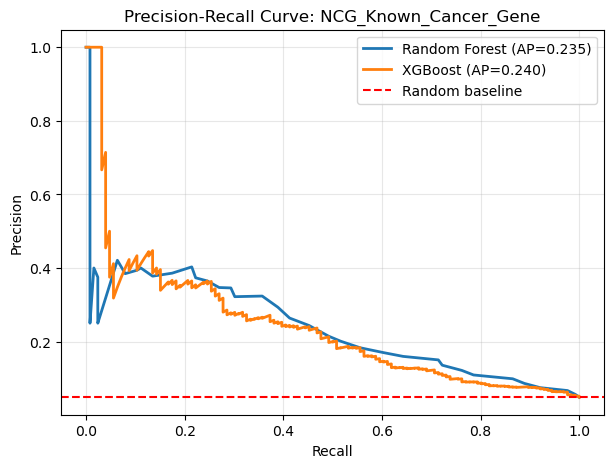

Random Forest - auPRC: 0.235
XGBoost - auPRC: 0.240



In [6]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'Bailey_et_al_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [7]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    11690
True      1218
Name: count, dtype: int64

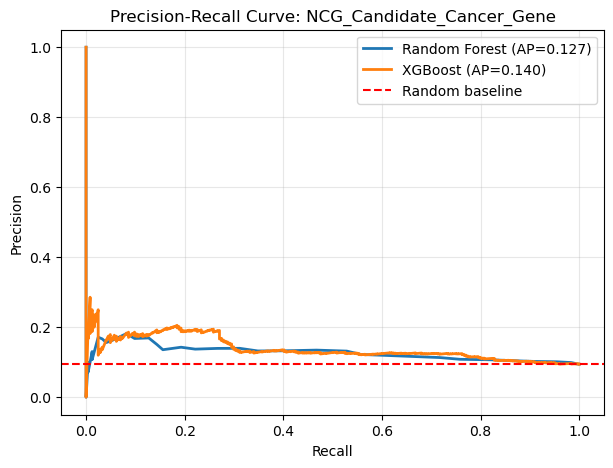

Random Forest - auPRC: 0.127
XGBoost - auPRC: 0.140



In [8]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [9]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    12412
True       496
Name: count, dtype: int64

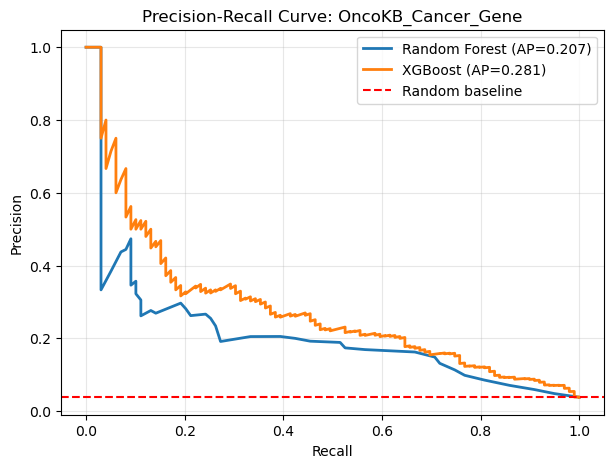

Random Forest - auPRC: 0.207
XGBoost - auPRC: 0.281



In [10]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [11]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    12640
True       268
Name: count, dtype: int64

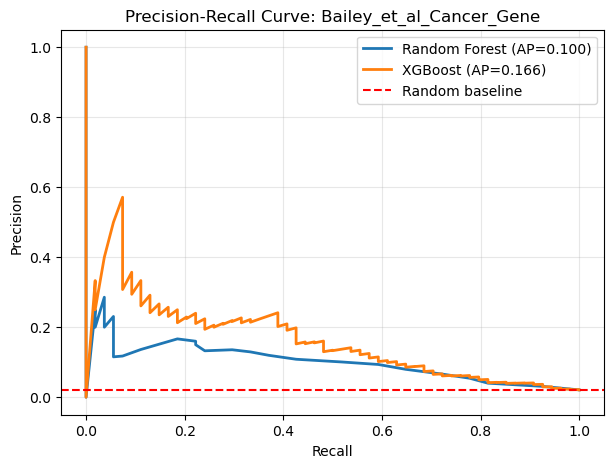

Random Forest - auPRC: 0.100
XGBoost - auPRC: 0.166



In [12]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'Bailey_et_al_Cancer_Gene')